In [1]:
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from sklearn.model_selection import train_test_split

import scipy.optimize as opt

In [2]:
data = pd.read_csv('cancer.csv')

df = data.copy()

df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


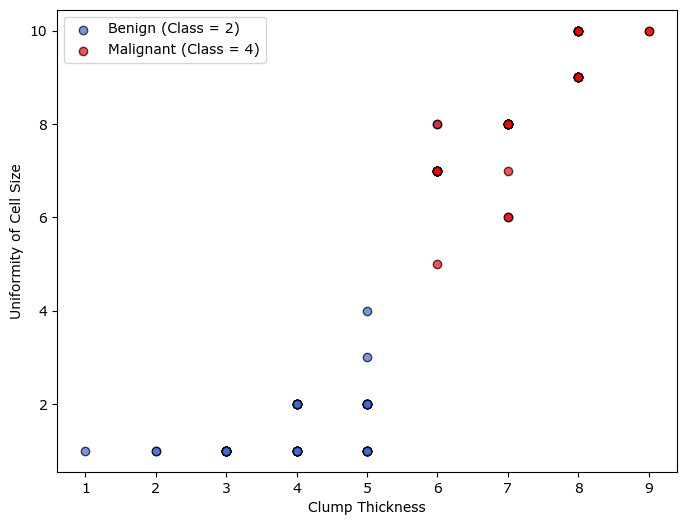

In [3]:
class_2 = df[df['Class'] == 2]
class_4 = df[df['Class'] == 4]

plt.figure(figsize = (8, 6))

plt.scatter(class_2['Clump'], class_2['UnifSize'], color = 'royalblue', edgecolor = 'k', label = 'Benign (Class = 2)', alpha = 0.7)
plt.scatter(class_4['Clump'], class_4['UnifSize'], color = 'Red', edgecolor = 'k', label = 'Malignant (Class = 4)', alpha = 0.7)

plt.xlabel('Clump Thickness')
plt.ylabel('Uniformity of Cell Size')

plt.legend()
plt.show()

In [4]:
x = df.drop('Class', axis = 1)

y = df[['Class']]

In [5]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = 0.2, random_state = 7)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_x_normalize = scaler.fit_transform(train_x)
test_x_normalize = scaler.transform(test_x)

In [7]:
from sklearn import svm

clf = svm.SVC(kernel = 'linear', probability = True, random_state = 7)
#Kernel: lineaer (line), rbf (complicated  ...), poly (n degree), sigmoid ( nervous system)
clf.fit(train_x_normalize, train_y['Class'])

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
y_pred = clf.predict(test_x_normalize)
y_pred_proba = clf.predict_proba(test_x_normalize)
from sklearn.metrics import classification_report, jaccard_score, log_loss

print()
print(classification_report(test_y, y_pred))
print()
print()
print("Jaccard 2: ", jaccard_score(test_y, y_pred, pos_label = 2))
print(f"Jaccard 4: {jaccard_score(test_y, y_pred, pos_label = 4):1.2f}")
print()
print(f"log_loss: {log_loss(test_y, y_pred_proba):1.2f}")


              precision    recall  f1-score   support

           2       0.90      1.00      0.95         9
           4       1.00      0.92      0.96        12

    accuracy                           0.95        21
   macro avg       0.95      0.96      0.95        21
weighted avg       0.96      0.95      0.95        21



Jaccard 2:  0.9
Jaccard 4: 0.92

log_loss: 0.14


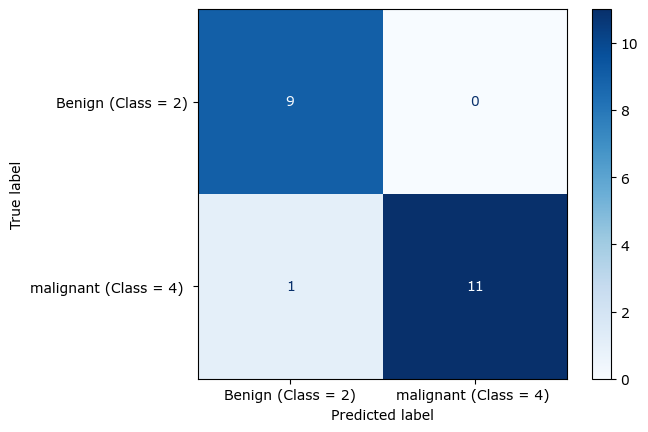

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(clf, test_x_normalize, test_y, display_labels = ['Benign (Class = 2)', 'malignant (Class = 4) '], cmap = plt.cm.Blues)